#**Nama: MUHAMMAD FAUZAN ADHIM HUSNUDDIN**

#NIM: 25/557151/PA/23405

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

img = cv2.imread('/content/drive/My Drive/pcd/high_res1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#AVERAGE DOWNSAMPLING

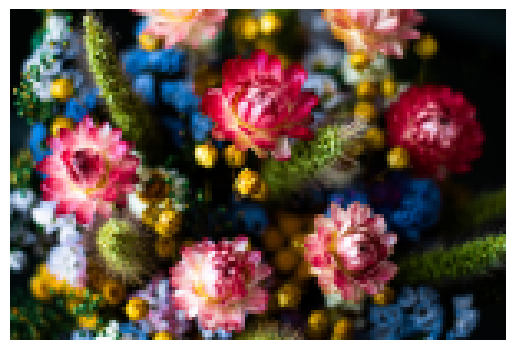

In [ ]:
def downSamplingAverage(img_rgb, k):
        H, W, C = img_rgb.shape
        new_H = H // k
        new_W = W // k

        result = np.zeros((H//k, W//k, C), dtype = np.uint8)
        for i in range(new_H):
            for j in range(new_W):
              block = img_rgb[i * k : (i + 1) * k, j * k : (j + 1) * k]
              result[i, j] = np.mean(block, axis=(0, 1))
        return result
img_result = downSamplingAverage(img_rgb, 8)
plt.imshow(img_result)
plt.axis('off')
plt.show()

#MAX DOWNSAMPLING

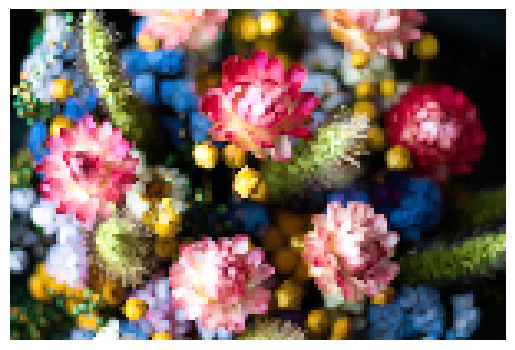

True

In [ ]:
#Down-sampling menggunakan metode max

def downSamplingMax(img_rgb, k):
        H, W, C = img_rgb.shape
        new_H = H // k
        new_W = W // k

        result = np.zeros((H//k, W//k, C), dtype = np.uint8)
        for i in range(new_H):
            for j in range(new_W):
              block = img_rgb[i * k : (i + 1) * k, j * k : (j + 1) * k]
              result[i, j] = np.max(block, axis=(0, 1))
        return result
img_result = downSamplingMax(img_rgb, 8)
plt.imshow(img_result)
plt.axis('off')
plt.show()

#MIN DOWNSAMPLING

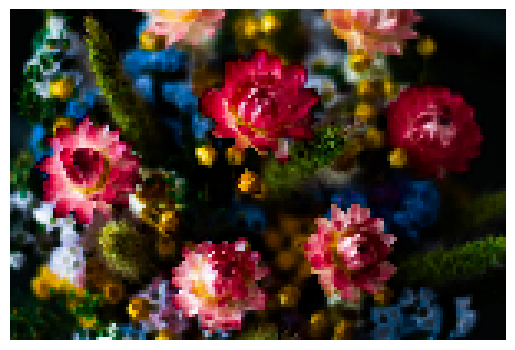

In [ ]:
def downSamplingMin(img_rgb, k):
        H, W, C = img_rgb.shape
        new_H = H // k
        new_W = W // k

        result = np.zeros((H//k, W//k, C), dtype = np.uint8)
        for i in range(new_H):
            for j in range(new_W):
              block = img_rgb[i * k : (i + 1) * k, j * k : (j + 1) * k]
              result[i, j] = np.min(block, axis=(0, 1))
        return result
img_result = downSamplingMin(img_rgb, 8)
plt.imshow(img_result)
plt.axis('off')
plt.show()

#HASIL DOWNSAMPLING

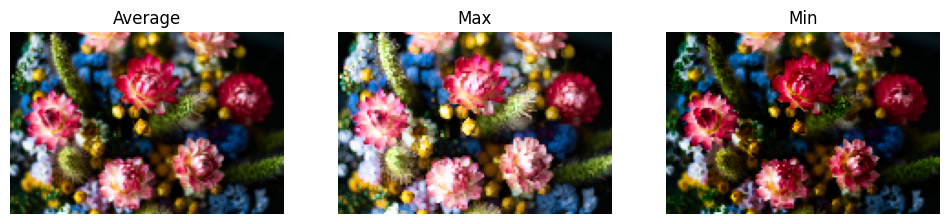

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(downSamplingAverage(img_rgb, 8))
plt.axis("off")
plt.title("Average")

plt.subplot(1, 3, 2)
plt.imshow(downSamplingMax(img_rgb, 8))
plt.axis("off")
plt.title("Max")

plt.subplot(1, 3, 3)
plt.imshow(downSamplingMin(img_rgb, 8))
plt.axis("off")
plt.title("Min")

plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

img = cv2.imread('/content/drive/My Drive/pcd/low_res.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#NEAREST NEIGHBOUR UPSAMPLING

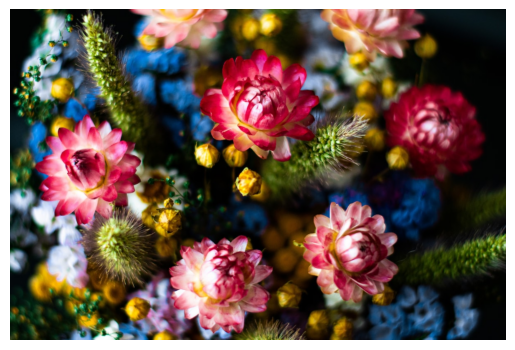

In [ ]:
def upSamplingNearestNeighbour(img_gray, k):
      H, W, C = img_gray.shape
      new_H = H * k
      new_W = W * k

      result = np.zeros((new_H, new_W, C), dtype = np.uint8)
      for i in range(new_H):
        for j in range(new_W):
          src_i = i // k
          src_j = j // k

          result[i, j] = img_gray[src_i, src_j]
      return result

img_result = upSamplingNearestNeighbour(img_rgb, 4)
plt.imshow(img_result)
plt.axis('off')
plt.show()

#BILINEAR INTERPOLATION UPSAMPLING

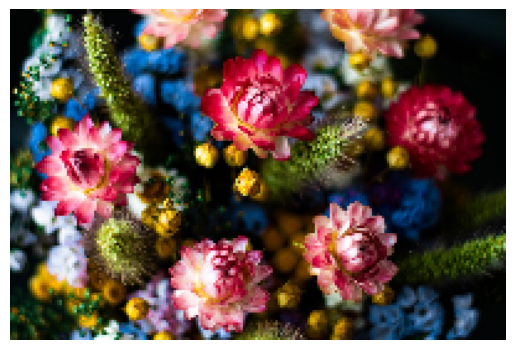

In [ ]:
def upSamplingBilinear(img_rgb, k):
    H, W, C = img_rgb.shape
    new_H = H * k
    new_W = W * k

    result = np.zeros((new_H, new_W, C), dtype=np.uint8)

    for i in range(new_H):
        for j in range(new_W):
            t = j / k
            s = i / k
            x1 = int(t)
            y1 = int(s)

            x2 = min(x1 + 1, W - 1)
            y2 = min(y1 + 1, H - 1)

            q11 = img_rgb[y1, x1]
            q21 = img_rgb[y1, x2]
            q12 = img_rgb[y2, x1]
            q22 = img_rgb[y2, x2]

            dx = t - x1
            dy = s - y1

            interpolated_bottom_row = q11 * (1 - dx) + q21 * dx
            interpolated_top_row = q12 * (1 - dx) + q22 * dx

            pixel_value = (
                interpolated_bottom_row * (1 - dy) + interpolated_top_row * dy
            )

            result[i, j] = np.clip(pixel_value, 0, 255)

    return result
img_result = upSamplingBilinear(img_rgb, 4)
plt.imshow(img_result)
plt.axis('off')
plt.show()

#BICUBIC INTERPOLATION UPSAMPLING

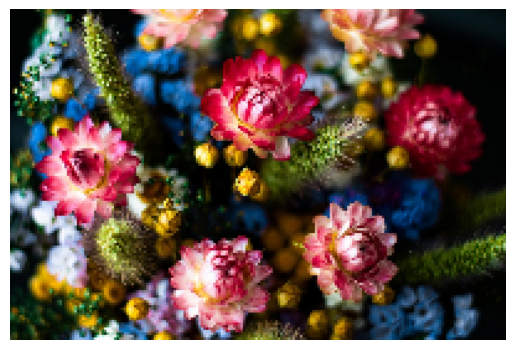

In [ ]:
def cubic_kernel(x, a=-0.5):
    x = abs(x)
    if x <= 1:
        return (a + 2) * x**3 - (a + 3) * x**2 + 1
    elif x < 2:
        return a * x**3 - 5 * a * x**2 + 8 * a * x - 4 * a
    else:
        return 0.0


def upSamplingBicubic(img_rgb, k):
    H, W, C = img_rgb.shape
    new_H = H * k
    new_W = W * k

    result = np.zeros((new_H, new_W, C), dtype=np.uint8)
    for i in range(new_H):
        for j in range(new_W):
            t = j / k
            s = i / k

            x1 = int(t)
            y1 = int(s)

            dx = t - x1
            dy = s - y1

            pixel_value = np.zeros(C, dtype=np.float64)

            for m in range(-1, 3):
                yy = min(max(y1 + m, 0), H - 1)
                wy = cubic_kernel(m - dy)

                row_value = np.zeros(C, dtype=np.float64)
                for n in range(-1, 3):
                    xx = min(max(x1 + n, 0), W - 1)
                    wx = cubic_kernel(n - dx)
                    row_value += img_rgb[yy, xx] * wx

                pixel_value += row_value * wy

            result[i, j] = np.clip(pixel_value, 0, 255)

    return result


img_result = upSamplingBicubic(img_rgb, 4)
plt.imshow(img_result)
plt.axis("off")
plt.show()